# The Individual Correlates of the Trump Vote (2016)

##  Opis datasetu

Ten zbiór danych pochodzi z badania **Cooperative Congressional Election Study (CCES) 2016** i opisuje indywidualne cechy respondentów w USA oraz ich deklarowane głosowanie w wyborach prezydenckich 2016.


Źródło:  
https://www.kaggle.com/datasets/utkarshx27/the-individual-correlates-of-the-trump-vote

---

##  Struktura danych


Najważniejsze zmienne:

###  Zmienna docelowa
- `votetrump` → 1 jeśli respondent głosował na Donalda Trumpa, 0 w przeciwnym przypadku

###  Dane demograficzne
- `age` → wiek respondenta
- `female` → 1 = kobieta, 0 = mężczyzna
- `racef` → rasa respondenta
- `state` → stan USA
- `collegeed` → wykształcenie (ukończone studia = 1)

###  Zmienne polityczne i społeczne
- `ideo` → ideologia (od liberalnej do konserwatywnej)
- `pid7na` → identyfikacja partyjna (Demokrata–Republikanin)
- `religimp` → ważność religii
- `bornagain` → chrześcijanin „born-again”

### Zmienne społeczne i psychologiczne
- `whiteadv` → przekonanie o przywilejach białych
- `fearraces` → lęk międzyrasowy
- `angryracism` → postawa wobec rasizmu
- `racerare` → przekonanie, że rasizm jest rzadki
---

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report,confusion_matrix
df = pd.read_csv(
    'data.csv')
df_with_empty=df.copy()
print("Przed usunięciem wartości pustych:",df.shape)
df.dropna(inplace=True)
print("Po usunieciu: ",df.shape)


Przed usunięciem wartości pustych: (64600, 22)
Po usunieciu:  (37591, 22)


In [5]:
#Downcasting
def Downcast(df):
    mem_before = df.memory_usage(deep=True).sum()/1e6
    print(f'Pamięć przed optymalizacją: {mem_before} MB')


    bool_cols = [
     "votetrump",
    "female",
    "collegeed",
    "bornagain"
    ]

    category_cols = [
    "state",
    "racef",
    "famincr"
    ]

    int_cols = [
    "age",
    "ideo",
    "pid7na",
    "religimp",
    "churchatd",
    "prayerfreq",
    "angryracism",
    "whiteadv",
    "fearraces",
    "racerare"
    ]

    float_cols = [
    "lrelig",
    "lcograc",
    "lemprac"
    ]

    df[bool_cols] = df[bool_cols].astype("bool")
    df[category_cols] = df[category_cols].astype("category")
    df[int_cols] = df[int_cols].astype("Int8")
    df[float_cols] = df[float_cols].astype("float32")

    mem_after=df.memory_usage(deep=True).sum()/ 1e6
    print(f'Po opytymalizacji: {mem_after} MB')
    print(f'Oszczędność: {100*(1- (mem_after/mem_before)):.1f}%')
    return df

In [6]:
df=Downcast(df)

Pamięć przed optymalizacją: 10.514656 MB
Po opytymalizacji: 2.371724 MB
Oszczędność: 77.4%


Feature engineering
Do naszego datasetu dodamy średnią wieku głosujących na Trumpa oraz nie grupując po stanie oraz wyrazimy to jako róznice. 

In [7]:
trump_voter_mean_age_by_state = df[df["votetrump"]].groupby("state")["age"].mean()
hillary_voter_mean_age_by_state = df[df["votetrump"] == 0].groupby("state")["age"].mean()
trump_voter_age_gap= trump_voter_mean_age_by_state - hillary_voter_mean_age_by_state
df["trump_voter_age_gap_by_state"] = df["state"].map(
    trump_voter_age_gap)
df.head()

,rownames,uid,state,votetrump,age,female,collegeed,racef,famincr,ideo,...,churchatd,prayerfreq,angryracism,whiteadv,fearraces,racerare,lrelig,lcograc,lemprac,trump_voter_age_gap_by_state
4,5,5,Colorado,False,34,True,True,White,7.0,2,...,1,2,2,1,1,1,-1.130175,-1.204085,-0.138715,4.202793
6,7,7,Texas,True,54,False,False,White,3.0,5,...,5,7,2,5,2,2,1.171097,0.508762,0.204095,6.476264
8,9,9,Georgia,True,53,False,False,White,4.0,4,...,3,6,3,4,1,2,-0.263387,0.301278,0.070166,4.415734
9,10,10,Pennsylvania,True,59,True,False,White,7.0,3,...,2,4,3,5,1,3,-0.066305,0.900038,0.070166,4.292601
10,11,11,Hawaii,False,70,True,True,Asian,10.0,3,...,2,3,1,2,3,2,-0.465141,-0.118812,0.052228,6.896479


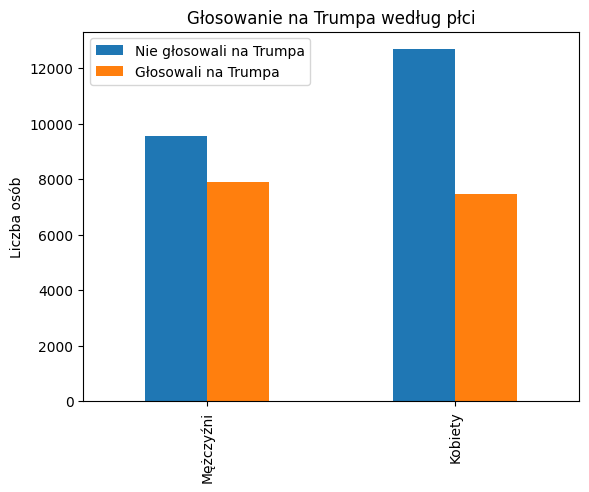

In [8]:


table=pd.crosstab(df["female"],df["votetrump"])
table.index=["Mężczyźni","Kobiety"]
table.columns=["Nie głosowali na Trumpa","Głosowali na Trumpa"]

table.plot(kind="bar")
plt.ylabel("Liczba osób")
plt.title("Głosowanie na Trumpa według płci")
plt.show()

Podobna liczba kobiet i mężczyzn głosowała na Trumpa

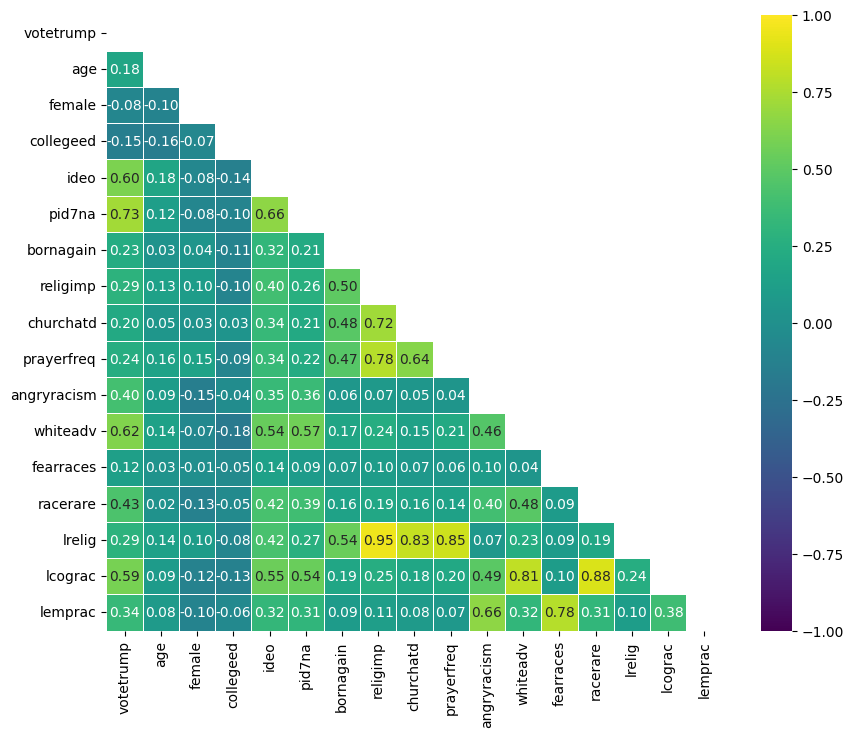

In [9]:
dtypes=df.select_dtypes(include=["number","bool"])
filtered = dtypes.drop(columns=["uid","rownames"])
corr=filtered.corr()
mask=np.triu(np.ones_like(corr,dtype=bool))
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='viridis', vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", square=True, linewidths=.5, mask=mask)
plt.show()

## Analiza korelacji

Na podstawie macierzy korelacji można zauważyć, że nie występuje istotna zależność pomiędzy głosowaniem na Donalda Trumpa (`votetrump`) a następującymi cechami:

- płcią (`female`),
- wiekiem (`age`),
- posiadaniem wykształcenia wyższego (`collegeed`),
- obawą przed osobami innych ras (`fearraces`),
- religijnoscią (`Irelig`,`religimp`,`preyfreq`),

Istnieje lekka korelacja pomiędzy wyborcami Trumpa a:
- przekonaniem że rasizm w USA jest zjawiskiem rzadkim (`racerare`),
- oburzeniem związanym z instnieniem zjawiska rasizmu (`angryracism`),

Istnieje duża korelacja pomiędzy wyborcami Trumpa a:
- poglądami konserwatywnymi oraz poparciem dla republikan (`ideo`,`pid7na`),
- przekonaniem że biali obywatele USA nie mają przewagi nad innymi obywatelami (`whiteadv`),
- Wektorem liczbowym stanowiący latentne oszacowanie rasizmu poznawczego, utworzony na podstawie zmiennych (`racerare`) i (`whiteadv`),



In [10]:
def scoreModel(y_test, y_pred):
    print("Ocena modelu:")
    print(classification_report(y_test, y_pred))
    print("Confusion matrix:")
    conf = confusion_matrix(y_test, y_pred)
    sns.heatmap(conf, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion matrix dla klasyfikacji")
    plt.ylabel("Prawda")
    plt.xlabel("Predykcja")
    plt.show()
    coef_dt = pd.DataFrame({"feature": model.coef_[0], "coef": X.columns})
    print(coef_dt)

Ocena modelu:
              precision    recall  f1-score   support

       False       0.91      0.91      0.91      4460
        True       0.87      0.87      0.87      3059

    accuracy                           0.89      7519
   macro avg       0.89      0.89      0.89      7519
weighted avg       0.89      0.89      0.89      7519

Confusion matrix:


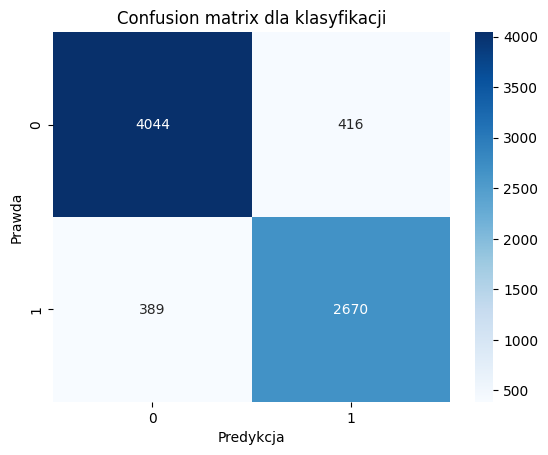

     feature         coef
0   0.015637          age
1  -0.109789       female
2  -0.410806    collegeed
3   0.506840         ideo
4   0.699041       pid7na
5   0.280503    bornagain
6   0.282250     religimp
7  -0.055009    churchatd
8   0.026454   prayerfreq
9   0.262938  angryracism
10  0.513437     whiteadv
11  0.199194    fearraces
12  0.135037     racerare
13 -0.139949       lrelig
14  0.273996      lcograc
15 -0.003955      lemprac


In [11]:
X=filtered.drop(columns=["votetrump"])
y=df["votetrump"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
scoreModel(y_test, y_pred)

Po usunięciu kolumn z deklaracją ideologi (skali liberał-konserwatysta oraz demokrat-republikan)

In [12]:
X = filtered.drop(columns=["votetrump", "pid7na", "ideo"])
y = df["votetrump"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Ocena modelu:
              precision    recall  f1-score   support

       False       0.84      0.86      0.85      4460
        True       0.79      0.76      0.77      3059

    accuracy                           0.82      7519
   macro avg       0.81      0.81      0.81      7519
weighted avg       0.82      0.82      0.82      7519

Confusion matrix:


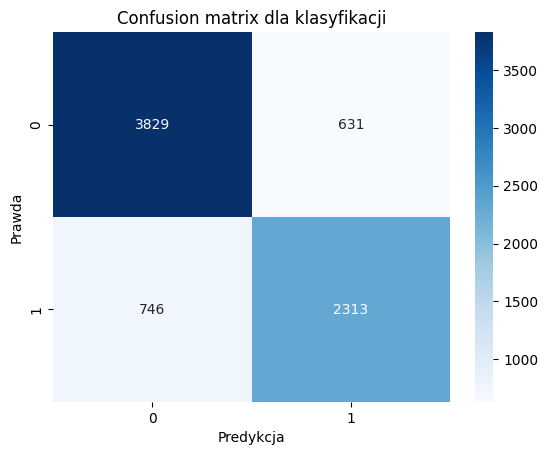

     feature         coef
0   0.017081          age
1  -0.209701       female
2  -0.233624    collegeed
3   0.457680    bornagain
4   0.135914     religimp
5  -0.047551    churchatd
6  -0.003152   prayerfreq
7   0.128496  angryracism
8   0.496247     whiteadv
9  -0.075830    fearraces
10 -0.232959     racerare
11  0.357373       lrelig
12  1.465663      lcograc
13  0.937395      lemprac


In [13]:
scoreModel(y_test,y_pred)


Po usunięciu deklaracji ideologicznej precyzja modelu spada o około 10%.
Najsilnieszymi cechami przemawiającymi o głosowaniu na trumpa są:
- Wektor liczbowy stanowiący latentne (ukryte) oszacowanie rasizmu poznawczego, wyprowadzone na podstawie zmiennych (`racerare`) i (`whiteadv`).
- Wektor liczbowy stanowiący latentne (ukryte) oszacowanie rasizmu emocjonalnego, wyprowadzone na podstawie zmiennych (`fearraces`) i (`angryracism`).
- Wektor liczbowy wskazujący deklarację respondenta dotyczącą przynależności do grupy chrześcijan ponownie narodzonych (`bornagain`).


# Trening z przeskalowanymi cechami
Kolejnym krokiem będzie wykonanie podobnego treningu ale tym razem z skalowaniem danych wejściowych.

Ocena modelu:
              precision    recall  f1-score   support

       False       0.84      0.86      0.85      4460
        True       0.79      0.76      0.77      3059

    accuracy                           0.82      7519
   macro avg       0.81      0.81      0.81      7519
weighted avg       0.82      0.82      0.82      7519

Confusion matrix:


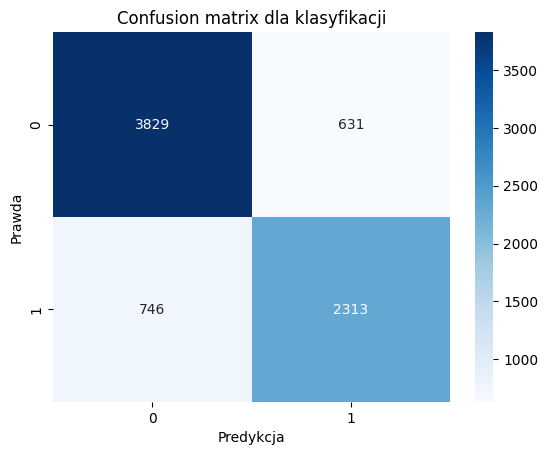

     feature         coef
0   0.270630          age
1  -0.105089       female
2  -0.114847    collegeed
3   0.202848    bornagain
4   0.159667     religimp
5  -0.080330    churchatd
6  -0.005990   prayerfreq
7   0.117191  angryracism
8   0.730301     whiteadv
9  -0.091149    fearraces
10 -0.283061     racerare
11  0.339378       lrelig
12  1.207158      lcograc
13  0.448668      lemprac


In [14]:
scaler=StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
scoreModel(y_test,y_pred)

# Wnioski po skalowaniu
Skalowanie danych wejściowych dało ten sam wynik co bez skalowania, jednak czas treningu znacznie się zmniejszył dla stosunkowo małych danych (0.1s vs 0.3s).

Skoro skalowanie danych nie zmienia wyniku dla regresji logistycznej, spróbujmy nie odrzucać wartości pustych tak jak na początku, a spróbujmy je uśrednić - uzyskamy w ten sposób więcej danych wejściowych które mogą pozwolić nam lepiej wyszkolić model. Jeśli jednak uśrednione wartości nie będą odzwierciedlały poprawnie danych rzeczywistych, model będzie pogorszony.



In [15]:
df_with_empty=Downcast(df_with_empty)
dtypes = df_with_empty.select_dtypes(include=["number", "bool"])
filtered = dtypes.drop(columns=["uid", "rownames"])
X = filtered.drop(columns=["votetrump", "pid7na", "ideo"])
y = df_with_empty["votetrump"]

Pamięć przed optymalizacją: 17.555491 MB
Po opytymalizacji: 3.556623 MB
Oszczędność: 79.7%


Ocena modelu:
              precision    recall  f1-score   support

       False       0.79      0.70      0.74      5157
        True       0.82      0.87      0.84      7763

    accuracy                           0.81     12920
   macro avg       0.80      0.79      0.79     12920
weighted avg       0.80      0.81      0.80     12920

Confusion matrix:


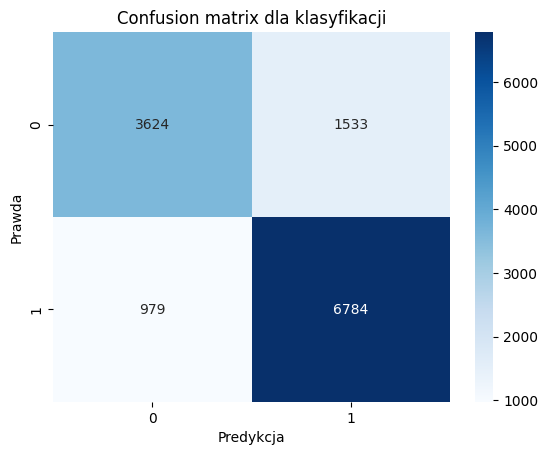

     feature         coef
0  -0.402878          age
1  -0.138728       female
2  -0.324455    collegeed
3   0.153305    bornagain
4   0.115098     religimp
5  -0.059564    churchatd
6  -0.046441   prayerfreq
7   0.412701  angryracism
8   1.022179     whiteadv
9   0.197630    fearraces
10  0.201626     racerare
11  0.244499       lrelig
12  0.091614      lcograc
13 -0.027299      lemprac


In [16]:

scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

imputer=SimpleImputer(strategy="mean")

X_train=imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

X_train = scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
scoreModel(y_test, y_pred)

# Wnioski
Jak widać wypełnienie wartościami średnimi brakujących danych pogorszyło precyzyjność modelu.
Uśrednienie wartości sprawiło że model znalazł odwrotną korelację z wiekiem wyborcy oraz studiowaniem. Ponadto, zaniżył znaczenie bycia osobą religijną oraz wskaznikami dotyczących równości, co niepokrywa się z poprzednimi wynikami bazującymi na 100% prawdziwych danych.